# Build-up phase: Effective Playing Space and formation stretching

*Using Projective Transformation for the Spatial Analysis of Team Behaviors in Football*

In the build-up phase within the midfield zone, the "Effective Playing Space" of both teams is examined using the Convex Hull algorithm, alongside the degree of play stretching, assessed through an analysis of formation centroids.

This notebook runs the shared pipeline (`pitchvision`: detection, tracking, pitch calibration, team classification - see `00_pipeline_demo.ipynb` for a step-by-step walkthrough with sanity checks, and `01_goal_scoring_opportunity.ipynb` for the jersey-colour clustering audit tools) condensed into one setup section, then applies two spatial analyses to a clip from the `BuildingAction` folder:

1. **Effective Playing Space**: each team's own convex hull (the smallest polygon containing all of that team's outfield players) as well as both teams combined (the classical Frencken et al. definition) - how much of the pitch is actively being used.
2. **Degree of stretching**: each team's own formation centroid/stretch (reusing `pitchvision.compactness`), plus the distance *between* the two teams' centroids - how far the build-up pulls the two blocks apart, split into the pitch's length-axis and width-axis components.

## 1. Setup

**If you've already run a notebook earlier in the current Colab session** and are re-pulling newer code: Python caches `pitchvision` in memory after the first `import`, so a `git pull` alone won't pick up new/changed symbols in already-running cells. After pulling, use **Runtime > Restart session**, then **Run all** - the commit hash printed below should match the latest commit on GitHub.

In [1]:
import os
import sys

REPO_URL = "https://github.com/Batomet/Magisterka.git"
BRANCH = "claude/football-spatial-analysis-thesis-lx13x7"
REPO_DIR = "/content/Magisterka"

if not os.path.isdir(REPO_DIR):
    !git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}
!git pull
!git log -1 --oneline

# Put the package on sys.path directly, rather than relying on `pip install -e .`
# to register it - editable installs use a .pth/import-finder file that Python's
# site module only processes at interpreter startup, so one run mid-session (in
# an already-running Colab kernel) doesn't reliably become importable.
SRC_DIR = os.path.join(REPO_DIR, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

Cloning into '/content/Magisterka'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 141 (delta 77), reused 109 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 3.71 MiB | 10.91 MiB/s, done.
Resolving deltas: 100% (77/77), done.
/content/Magisterka
Already up to date.
cb08699 (HEAD -> claude/football-spatial-analysis-thesis-lx13x7, origin/claude/football-spatial-analysis-thesis-lx13x7, origin/HEAD) Add build-up phase analysis: Effective Playing Space + formation stretching


In [2]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 588.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00


## 2. Mount Drive and pick a clip

In [3]:
from pitchvision import DriveConfig, list_videos, mount_drive

mount_drive()

# Adjust `root` if BuildingAction/Goals/SetPieces don't live directly under My Drive.
drive_cfg = DriveConfig(root="/content/drive/MyDrive/Magisterka")
buildup_videos = list_videos(drive_cfg.building_action_path)
print(f"Found {len(buildup_videos)} videos in BuildingAction/")

sample_video = buildup_videos[0]  # change the index to analyse a different clip
sample_video

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Found 45 videos in BuildingAction/


'/content/drive/MyDrive/Magisterka/BuildingAction/BuildingAction00049943.mp4'

## 3. Run the shared pipeline

Condensed: pitch calibration (automatic, from detected pitch keypoints) and team classification (jersey colour, using the specialized player/goalkeeper/referee detector). If either step needs troubleshooting for this particular clip, do it in `00_pipeline_demo.ipynb` first.

In [4]:
import cv2
import matplotlib.pyplot as plt

from pitchvision import PitchKeypointDetector, VideoFrames, download_pitch_keypoint_weights

frames = VideoFrames(sample_video)
first_frame = frames.read_frame(0)

pitch_weights_path = download_pitch_keypoint_weights(
    "/content/drive/MyDrive/pitchvision_models/football-pitch-detection.pt"
)
keypoint_detector = PitchKeypointDetector(weights=pitch_weights_path, confidence=0.5)
calibrator = keypoint_detector.calibrate(first_frame)
print("Pitch calibrated.")

Pitch calibrated.


Collected 500 jersey colour samples


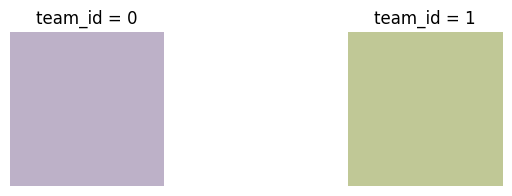

In [5]:
import numpy as np

from pitchvision import (
    PlayerBallDetector,
    SPORTS_DETECTION_CLASSES,
    TeamClassifier,
    collect_jersey_samples,
    download_player_detection_weights,
)

player_weights_path = download_player_detection_weights(
    "/content/drive/MyDrive/pitchvision_models/football-player-detection.pt"
)
player_detector = PlayerBallDetector(
    weights=player_weights_path, confidence=0.3, classes=SPORTS_DETECTION_CLASSES, imgsz=1280
)

jersey_samples = collect_jersey_samples(sample_video, player_detector, class_names=("player",), stride=15)
print(f"Collected {len(jersey_samples)} jersey colour samples")

team_classifier = TeamClassifier(n_clusters=2)
team_classifier.fit(np.array([s.color for s in jersey_samples]))

swatches = team_classifier.cluster_swatches
fig, axes = plt.subplots(1, len(swatches), figsize=(4 * len(swatches), 2))
for team_id, (ax, rgb) in enumerate(zip(axes, swatches)):
    ax.imshow([[rgb]])
    ax.set_title(f"team_id = {team_id}")
    ax.axis("off")
plt.show()

**Audit the fit before trusting it.** See `01_goal_scoring_opportunity.ipynb` for what to look for here - two visually separated blobs of roughly similar size in the scatter/crop grid below is trustworthy; one tight blob plus a handful of scattered outliers is not.

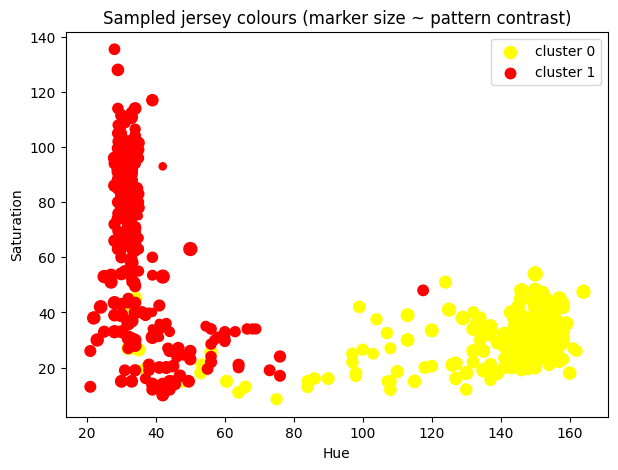

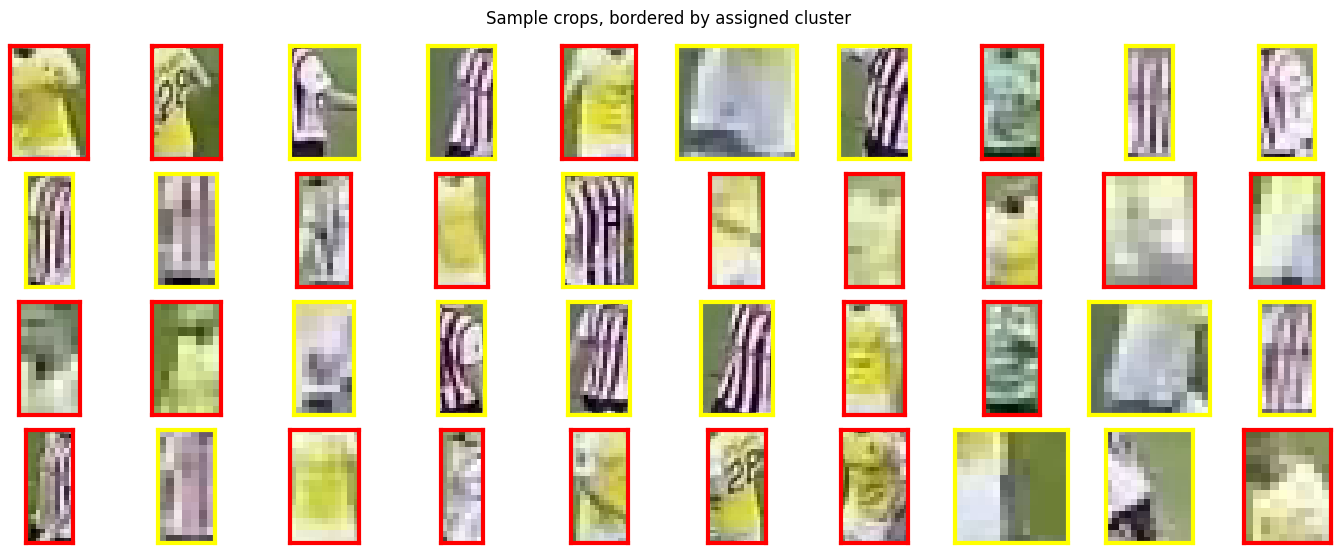

In [6]:
from pitchvision import plot_jersey_color_samples

cluster_labels = team_classifier.predict_from_colors(np.array([s.color for s in jersey_samples]))
plot_jersey_color_samples(jersey_samples, cluster_labels, cluster_colors={0: "yellow", 1: "red"})

In [7]:
from pitchvision import PlayerTracker, TrackingPipeline

TEAM_COLORS = {0: "yellow", 1: "red"}

tracker = PlayerTracker(weights=player_weights_path, confidence=0.3, classes=SPORTS_DETECTION_CLASSES, imgsz=1280)
pipeline = TrackingPipeline(
    tracker=tracker,
    calibrator=calibrator,
    team_classifier=team_classifier,
    team_eligible_class_names=("player",),
)

tracks_df = pipeline.run(sample_video, max_frames=250)
tracks_df["class_name"].value_counts()

,count
class_name,
player,5614
referee,640
ball,71
goalkeeper,31


## 4. Effective Playing Space (Convex Hull)

`pitchvision.compute_team_convex_hull` gives one row per frame with the area/perimeter of the smallest polygon containing one team's outfield players - a direct measure of how much pitch space that team is occupying. `compute_combined_convex_hull` does the same over both teams' players together (the classical Frencken et al. "Effective Playing Space" definition).

In [8]:
from pitchvision import compute_combined_convex_hull, compute_team_convex_hull

hull_team0 = compute_team_convex_hull(tracks_df, team_id=0)
hull_team1 = compute_team_convex_hull(tracks_df, team_id=1)
hull_combined = compute_combined_convex_hull(tracks_df)
hull_team0.head()

,frame,team_id,n_players,area_m2,perimeter_m
0,0,0,8,1035.263893,147.157917
1,1,0,8,1034.564732,147.128113
2,2,0,8,1034.925957,147.221596
3,3,0,8,1032.683460,147.107583
4,4,0,8,1030.723361,146.990280


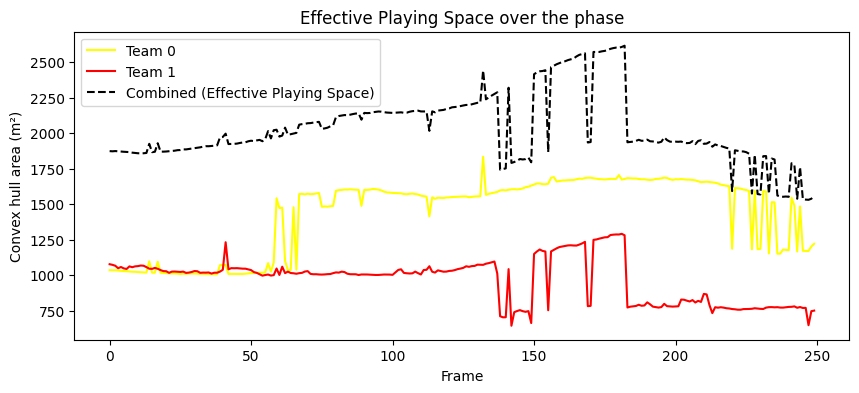

Team 0 hull area (m2): {'mean': 1435.6140358092066, 'min': 1006.496721304313, 'max': 1834.7994607166493}
Team 1 hull area (m2): {'mean': 970.3187453925947, 'min': 644.2072682841657, 'max': 1291.471198472708}
Combined EPS (m2): {'mean': 2028.0192479146783, 'min': 1531.234547554938, 'max': 2616.5679051399657}


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hull_team0["frame"], hull_team0["area_m2"], label="Team 0", color=TEAM_COLORS[0])
ax.plot(hull_team1["frame"], hull_team1["area_m2"], label="Team 1", color=TEAM_COLORS[1])
ax.plot(hull_combined["frame"], hull_combined["area_m2"], label="Combined (Effective Playing Space)", color="black", linestyle="--")
ax.set_xlabel("Frame")
ax.set_ylabel("Convex hull area (m\u00b2)")
ax.set_title("Effective Playing Space over the phase")
ax.legend()
plt.show()

print("Team 0 hull area (m2):", hull_team0["area_m2"].describe()[["mean", "min", "max"]].to_dict())
print("Team 1 hull area (m2):", hull_team1["area_m2"].describe()[["mean", "min", "max"]].to_dict())
print("Combined EPS (m2):", hull_combined["area_m2"].describe()[["mean", "min", "max"]].to_dict())

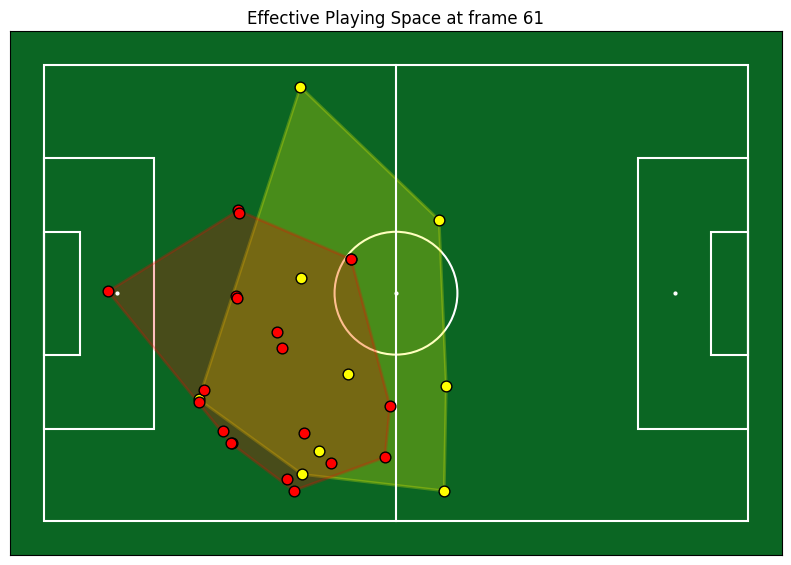

In [10]:
from pitchvision import draw_pitch, plot_convex_hull

# A representative frame: the one with the most on-pitch players tracked.
on_pitch = tracks_df[(tracks_df["class_name"] == "player") & tracks_df["team_id"].notna()]
sample_frame = on_pitch.groupby("frame").size().idxmax()
frame_rows = on_pitch[on_pitch["frame"] == sample_frame]

ax = draw_pitch()
for team_id, group in frame_rows.groupby("team_id"):
    positions = group[["pitch_x", "pitch_y"]].to_numpy()
    color = TEAM_COLORS.get(team_id, "gray")
    plot_convex_hull(ax, positions, color=color)
    ax.scatter(positions[:, 0], positions[:, 1], color=color, edgecolors="black", s=60, zorder=3)
plt.title(f"Effective Playing Space at frame {sample_frame}")
plt.show()

## 5. Degree of stretching (formation centroids)

Each team's own `stretch_index_m`/`length_m`/`width_m` (from `pitchvision.compute_team_compactness`, the same function `01_goal_scoring_opportunity.ipynb` uses for defensive compactness) describes that team's *internal* shape. `compute_centroid_separation` complements that with the distance *between* the two teams' centroids - how far the build-up has pulled the two blocks apart, split into length-axis (goal-to-goal) and width-axis (touchline-to-touchline) components.

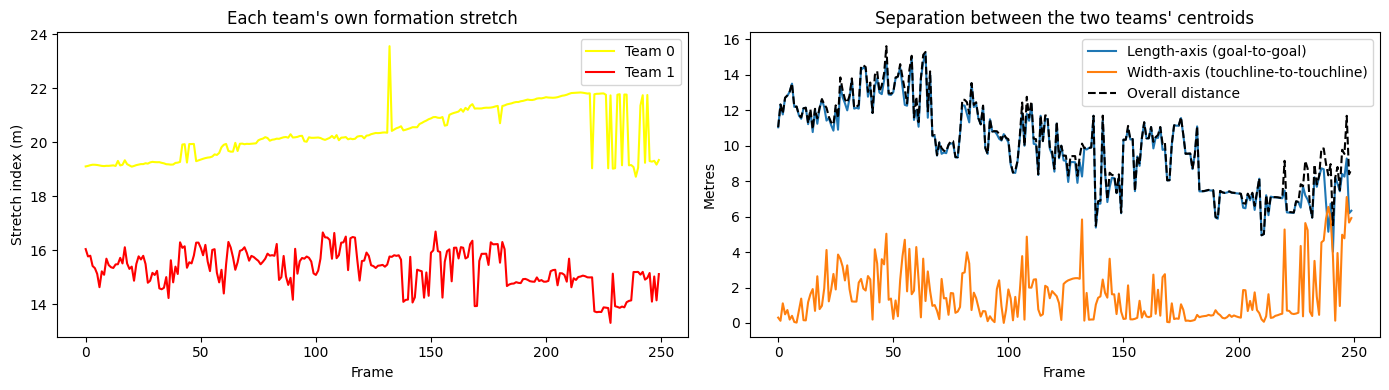

In [11]:
from pitchvision import compute_centroid_separation, compute_team_compactness

compactness0 = compute_team_compactness(tracks_df, team_id=0)
compactness1 = compute_team_compactness(tracks_df, team_id=1)
separation = compute_centroid_separation(tracks_df, team_a_id=0, team_b_id=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(compactness0["frame"], compactness0["stretch_index_m"], label="Team 0", color=TEAM_COLORS[0])
ax1.plot(compactness1["frame"], compactness1["stretch_index_m"], label="Team 1", color=TEAM_COLORS[1])
ax1.set_xlabel("Frame")
ax1.set_ylabel("Stretch index (m)")
ax1.set_title("Each team's own formation stretch")
ax1.legend()

ax2.plot(separation["frame"], separation["length_axis_separation_m"], label="Length-axis (goal-to-goal)")
ax2.plot(separation["frame"], separation["width_axis_separation_m"], label="Width-axis (touchline-to-touchline)")
ax2.plot(separation["frame"], separation["centroid_distance_m"], label="Overall distance", linestyle="--", color="black")
ax2.set_xlabel("Frame")
ax2.set_ylabel("Metres")
ax2.set_title("Separation between the two teams' centroids")
ax2.legend()
plt.tight_layout()
plt.show()

## 6. Save results

In [12]:
output_dir = "/content/drive/MyDrive/pitchvision_outputs"
os.makedirs(output_dir, exist_ok=True)
clip_name = os.path.splitext(os.path.basename(sample_video))[0]

hull_team0.to_csv(os.path.join(output_dir, f"{clip_name}_hull_team0.csv"), index=False)
hull_team1.to_csv(os.path.join(output_dir, f"{clip_name}_hull_team1.csv"), index=False)
hull_combined.to_csv(os.path.join(output_dir, f"{clip_name}_hull_combined.csv"), index=False)
compactness0.to_csv(os.path.join(output_dir, f"{clip_name}_compactness_team0.csv"), index=False)
compactness1.to_csv(os.path.join(output_dir, f"{clip_name}_compactness_team1.csv"), index=False)
separation.to_csv(os.path.join(output_dir, f"{clip_name}_centroid_separation.csv"), index=False)
print(f"Saved results to {output_dir}")

Saved results to /content/drive/MyDrive/pitchvision_outputs


### Batch-export Effective Playing Space diagrams

`save_convex_hull_frames` (like `save_voronoi_frames` in `01_goal_scoring_opportunity.ipynb`) works on *any* DataFrame shaped like `tracks_df` - a hand-built or previously-saved CSV works identically to a live pipeline result. See that notebook for the CSV schema if building your own input.

In [13]:
from pitchvision import save_convex_hull_frames

hull_dir = os.path.join(output_dir, f"{clip_name}_convex_hull")
saved_paths = save_convex_hull_frames(tracks_df, hull_dir, stride=10, team_colors=TEAM_COLORS)
print(f"Saved {len(saved_paths)} Effective Playing Space diagrams to {hull_dir}")
saved_paths[:5]

Saved 25 Effective Playing Space diagrams to /content/drive/MyDrive/pitchvision_outputs/BuildingAction00049943_convex_hull


['/content/drive/MyDrive/pitchvision_outputs/BuildingAction00049943_convex_hull/convex_hull_frame_00000.png',
 '/content/drive/MyDrive/pitchvision_outputs/BuildingAction00049943_convex_hull/convex_hull_frame_00010.png',
 '/content/drive/MyDrive/pitchvision_outputs/BuildingAction00049943_convex_hull/convex_hull_frame_00020.png',
 '/content/drive/MyDrive/pitchvision_outputs/BuildingAction00049943_convex_hull/convex_hull_frame_00030.png',
 '/content/drive/MyDrive/pitchvision_outputs/BuildingAction00049943_convex_hull/convex_hull_frame_00040.png']

## Notes and limitations

- Convex hull area only counts the *outermost* players - two teams with the same hull area can have very different internal density (e.g. one bunched near the hull's edges with an empty midfield, another evenly spread). Cross-reference with `stretch_index_m`/`mean_pairwise_distance_m` (`pitchvision.compactness`) for a fuller picture of a team's actual shape, not just its outer boundary.
- Goalkeepers are excluded from both the convex hull and compactness metrics by default, since a goalkeeper anchored deep in their own box would distort a midfield/build-up shape analysis that isn't about them.
- The combined Effective Playing Space can shrink even while one team's own hull grows, if the two teams' players are moving into overlapping space rather than spreading apart - the per-team and combined figures answer different questions and are both worth reporting.
- To compare these figures across multiple build-up sequences for the thesis's quantitative analysis, re-run this notebook per clip (change `sample_video` in section 2) and aggregate the saved CSVs.